Vamos dar incio a parte mais profunda do assunto, que é DL

Nesse curso vamos ter essas atividades 

Sumário
Introdução ao Deep Learning

1.1 O que é Deep Learning?

1.2 Por que Deep Learning agora?

1.3 Aplicações reais


Perceptron

2.1 Origem e inspiração biológica

2.2 Modelo matemático do Perceptron

2.3 Algoritmo de treinamento

2.4 Limitação do Perceptron: o problema XOR


Redes Neurais Artificiais (Multilayer Perceptron)

3.1 Arquitetura de uma MLP

3.2 Forward propagation

3.3 Backpropagation e o gradiente descendente

3.4 Inicialização de pesos


Funções de Ativação

4.1 Por que precisamos de não-linearidade?

4.2 Função Sigmoide

4.3 Tangente Hiperbólica (tanh)

4.4 ReLU (Rectified Linear Unit)

4.5 Softmax

4.6 Comparação e escolha


Funções de Perda (Loss Functions)

5.1 O papel da função de perda

5.2 Erro Quadrático Médio (MSE)

5.3 Entropia Cruzada (Cross-Entropy)

5.4 Escolha da função de perda



Otimizadores

6.1 Gradiente Descendente

6.2 Stochastic Gradient Descent (SGD)

6.3 Momentum

6.4 Adam (Adaptive Moment Estimation)

6.5 Comparação de otimizadores


Introdução ao TensorFlow/Keras

7.1 O que é TensorFlow?

7.2 Keras: a API de alto nível

7.3 Primeiro modelo: regressão com TensorFlow

7.4 Compilação e treinamento


Visão Geral do PyTorch

8.1 O que é PyTorch?

8.2 Principais diferenças entre TensorFlow e PyTorch

8.3 Exemplo conceitual em PyTorch

8.4 Qual escolher?


Classificação de Imagens com MNIST

9.1 O dataset MNIST

9.2 Preparação dos dados

9.3 Construindo uma MLP para MNIST

9.4 Treinamento e avaliação

9.5 Visualização dos resultados


Atividade Prática

10.1 Objetivo

10.2 Roteiro

10.3 Entrega


Conclusão e Próximos Passos


Referências

## Deep Learning 
Deep Learning é um subcampo do ML que utiliza redes neurais artificiais com múltiplas camadas (por isso o termo 'profundo') para aprender representações hierárquicas dos dados. Enquanto modelos clássicos de ML dependem de features extraídas manualmente, o DL é capaz de aprender automaticamente as características relevantes em diferentes níveis de abstração.

Definição mais técnica: DL refere-se a modelos paramétricos, não lineares e hierárquicos que são otimizados com gradiente descendente estocástico. A hierarquia é obtida empilhando camadas, onde a saída de uma camada serve como entrada para a próxima.

As redes neurais existem desde 1950, e o dl so explodiu nas ultimas décadas devido a alguns fatores : 

- Grades volumes de dados : O surgimento de datasets massivos como ImageNet(milhões de imagem rotulada) permitiu treinar modelos complexos sem overfitting.

- Hardware poderoso : GPUs(Unidades de Processamento Gráfico) possibilitaram a paralelização dos cálculos, reduzindo o tempo de treinamento de meses para dias/horas

- Avanços em algoritmos : Técnicas como ReLU, dropout, batch normalization e otimizadores eficientes(Adam) tornaram o treinamento de redes profundas viável


Um grande avanço tambem, foram as evoluções das bibliotecas com o tensorflow, pytorch e keras. Elas ajudaram a democratizar o acesso a essas tecnologias.

### Algumas áreas de DL

| Área                          | Aplicação                                              |
|-------------------------------|---------------------------------------------------------|
| Visão Computacional           | Reconhecimento facial, diagnóstico por imagem, carros autônomos |
| Processamento de Linguagem Natural | Tradução automática, chatbots, análise de sentimentos |
| Sistemas de Recomendação      | Netflix, Spotify, Amazon                               |
| Jogos                          | AlphaGo, OpenAI Five                                    |
| Biologia                       | Predição de estruturas de proteínas (AlphaFold)         |

## Perceptron

O perceptroon é a unidade fundamental das RNA(redes neurais artificiais). Biologicamente, um neuronio recebe sinais através de dentritos, processo no corpo ceulular e , se o estimulo ultrapassar um limiar, dispara um sinal pelo axonio

### Modelo matemático do perceptron

f(x; w, b) =  

\begin{cases} 
+1 & \text{se } w^T x + b \geq 0 \\
-1 & \text{caso contrário}
\end{cases}


Geometricamente, o perceptron reprenta um hiperplano que divide o espaço de features em duas regioes.
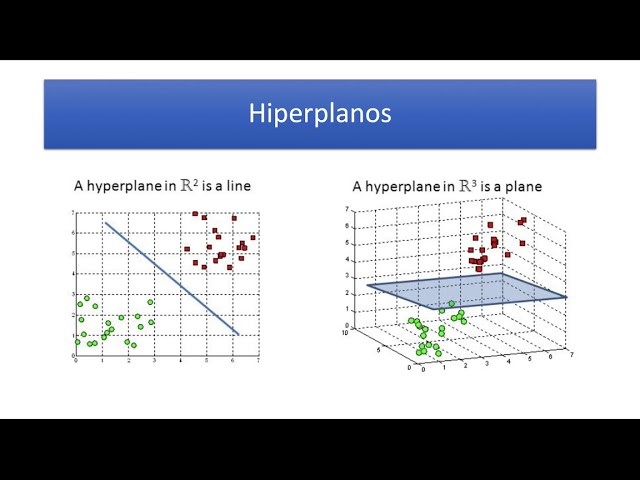




In [1]:
!pip install numpy matplotlib scikit-learn pandas

In [2]:
#Geometricamente, o perceptron representa um hiperplano que divide o espaço de features em duas partes, onde cada parte corresponde a uma classe diferente. O objetivo do treinamento do perceptron é encontrar os pesos e o bias que definem esse hiperplano de forma a maximizar a margem entre as classes.
#O processo de treinamento do perceptron envolve a atualização iterativa dos pesos e do bias com base nos erros cometidos durante a classificação. O algoritmo de treinamento do perceptron é conhecido como o algoritmo de aprendizado do perceptron, que é um método de otimização que busca minimizar o erro de classificação.
#O algoritmo de aprendizado do perceptron funciona da seguinte maneira:
import numpy as np
import pandas as pd

#Iniciando a classe Perceptron
class Perceptron:
    #Iniciando construtores
    def __init__(self, learning_rate = 0.01, n_iterations = 100):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None # Inicializando os pesos como None, eles serão atualizados durante o treinamento
        self.bias = None# Inicializando o bias como None, ele será atualizado durante o treinamento

    #Função de treinamento
    def fit(self, X, y):
        n_samples, n_features = X.shape #Obtendo o número de amostras e o número de features a partir do shape do array X
        self.weights = np.zeros(n_features) #Inicializando os pesos como um array de zeros com o mesmo número de features
        self.bias = 0 #Inicializando o bias como zero, voce deve sempre inicializar o bias, caso contrário, ele não será atualizado durante o treinamento

        y_ = np.array([1 if i > 0 else 0 for i in y]) #Convertendo as classes para 0 e 1, onde 1 representa a classe positiva e 0 representa a classe negativa

        for _ in range(self.n_iterations): #Iterando pelo número de iterações especificado
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias #Calculando a saída linear do perceptron, que é a soma ponderada das features mais o bias
                y_predicted = np.where(linear_output > 0, 1, -1) #Aplicando a função de ativação degrau para obter a previsão da classe, onde se a saída linear for maior que 0, a previsão é 1, caso contrário, é -1

                update = self.lr * (y_[idx] - y_predicted) #Calculando a atualização dos pesos e do bias com base no erro de classificação
                self.weights += update * x_i #Atualizando os pesos com base na atualização calculada
                self.bias += update #Atualizando o bias com base na atualização calculada

    #Função de previsão
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

### Algoritmo de treinamento 

O algoritmo do perceptron é iterativo e converge se os dados foram **linearmente separaveis  :**

1. Incialize pesos e bias com zeros (ou valores aleatórios pequenos)

2. Para cada amostra de treinamento:
    - Calcule a saida predita
    - Se a predição estiver errada, atualize os pesos

3. Repita até que todas as amostras sejam classificadas corretamente ou atinga o número maximo de épocas.



### Limitação do perceptron : o problema do XOR

Cientistas provaram que o perceptron de unica camada é incapaz de aprender funções não-linearmente separáveis, como XOR.
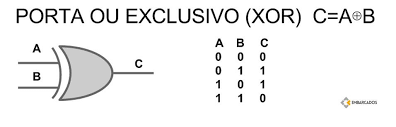

QUal motivo ? XOR nao pode ser spearada por uma unica linha reta (hiperplano). É necessário adicionar camadas intermediárias (hidden layers) para aprender representações nao-lineares. Esse problema levou ao desenvolvimento das MLP( Multi Layer Perceptron)


In [3]:
##Limitação do XOR
# Dados XOR
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

p = Perceptron(learning_rate=0.1, n_iterations=100)
p.fit(X_xor, y_xor)
pred = p.predict(X_xor)
print("Predições XOR:", pred)  # Não conseguirá aprender corretamente

Predições XOR: [ 1  1 -1 -1]


## Redes neurais artificiais - MLP (multilayer percepetron)

### Arquitetura de uma MLP. Ela é composta por:
1. Camada de entrada (input layer) : recebe os dados brutos
2. Camadas ocultas (hidden layers) : realizam transformações não-lineares
3. Camada de saida (output layer) : produz a predição final

Cada camada é formada por neuronios (ou unidades) que se contectam as todos os neuronios da camada seguinte (fully connected)

Entrada (x1) ---> [Camada Oculta 1] ---> [Camada Oculta 2] ---> Saída (y)  
     x2 -------->    (neurônios)          (neurônios)  
     x3 --------> 


### Forward propagation
O processo de forward calcula a saida da rede uma dada entrada

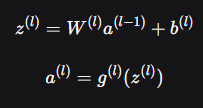

onde : 
 - a^(l) = X -> entrada
 - g^(l) é a função de ativação
 - A saida final é ^y = a^(L), onde L é o numero de camadas


 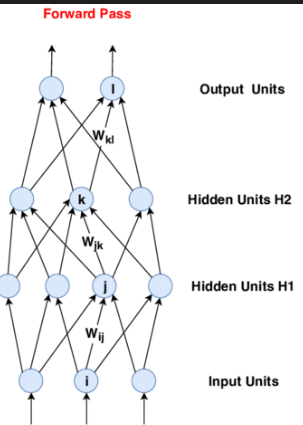

In [4]:
#Exempo :forward pass

'''
np.dot = Produto escalar (dot product)
multiplica elemento por elemento os valores de a (ativações e entrada) com pesos w e soma os resultados
em dl, usamos para combinar as entradas com os pesos aprendidos


act = função de ativação
Aplica uma transformação nao linear ao valor z
Funções comuns : relu, sigmoid, tanh
A função de ativação é crucial para introduzir não linearidade no modelo, permitindo que ele

O que é ser linear ?
Linear significa que a saída é uma combinação linear das entradas, ou seja, a saída pode ser expressa como uma soma ponderada das entradas. Em um modelo linear, a relação entre as entradas e a saída é representada por uma linha reta (ou um hiperplano em dimensões superiores). Isso limita a capacidade do modelo de capturar relações complexas entre as variáveis, o que pode resultar em um desempenho ruim em tarefas que envolvem padrões não lineares.

'''
def forward_pass(X, weights, bias):
    a = X #A entrada da camada é a saída da camada anterior, ou seja, a entrada da primeira camada é o próprio X, e a entrada das camadas subsequentes é a saída da camada anterior
    for w, b, act in zip(weights, bias, activations): #Iterando pelos pesos, bias e funções de ativação de cada camada
        z = np.dot(a, w) + b#Calculando a saída linear da camada, que é a soma ponderada das entradas mais o bias
        a = act(z) #Adicionando nao linearidade aplicando a função de ativação à saída linear


## Backpropagation e o gradiente descendente

O backpropagation(retropropagação) é um algoritmo essencial no treinamento de redes neurais. Ele calcula os gradientes da função de perda em relação a todos os pesos da rede, permitindo o ajuste dos pesos através do **gradiente descendente**.

### Gradiente no backpropagation
O gradiente indica como a função de erro muda em relação aos pesos da rede. Durante o backpropagation, o gradiente é calculado para cada peso, e ele é utilizado para ajustar os pesos na direção que minimiza o erro.

-> Como funciona o gradiente? 
    - O gradiente calcula a taxa de variação em relação aos pesos da rede.
    - Gradiente descendente : Atualiza os pesos na direação oposta ao gradiente, com objetivo de reduzir o erro da rede

-> Importancia do gradiente:
    - Ele orienta a rede sobre como ajustar seus pesos para melhorar as previsoes
    - O gradiente descendente usa esses gradientes para atualizar os pesos, minimizando a função de erro

Como funciona todo o processo ?
1. Calcule o erro na saída
2. Propague o erro para trás, camada por camada, usando a regra da cadeia
3. Calule os gradientes de cada peso
4. Atualize os pesos na direção oposta ao gradiente

Regra da cadeia para **uma camada** L:

\[
\frac{\partial W^{(l)}}{\partial L} = \frac{\partial z^{(l)}}{\partial L} \cdot \frac{\partial W^{(l)}}{\partial z^{(l)}} = \delta^{(l)} \cdot (a^{(l-1)})^T
\]

onde δ^(l) é o 'erro' propaagado para cada camada L


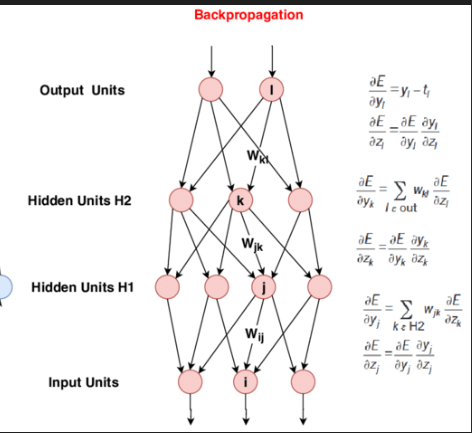





In [5]:
#Exemplo de codigo de retropapação
import numpy as np

# Função de ativação Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivada da função Sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

# Função de erro (MSE)
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Definir os dados de entrada e saída (exemplo simples)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # Dados de entrada
y = np.array([[0], [1], [1], [0]])  # Saída esperada (XOR)

# Inicializar pesos e bias
input_layer_neurons = X.shape[1]  # número de entradas
hidden_layer_neurons = 4  # número de neurônios na camada oculta
output_layer_neurons = 1  # número de neurônios na camada de saída

# Pesos aleatórios entre as camadas
weights_input_hidden = np.random.uniform(size=(input_layer_neurons, hidden_layer_neurons))
weights_hidden_output = np.random.uniform(size=(hidden_layer_neurons, output_layer_neurons))

# Biases aleatórios
bias_hidden = np.random.uniform(size=(1, hidden_layer_neurons))
bias_output = np.random.uniform(size=(1, output_layer_neurons))

# Taxa de aprendizado
learning_rate = 0.1

# Número de iterações (épocas)
epochs = 10000

# Backpropagation
for epoch in range(epochs):
    # **Forward propagation**
    hidden_layer_activation = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_layer_output = sigmoid(hidden_layer_activation)
    
    output_layer_activation = np.dot(hidden_layer_output, weights_hidden_output) + bias_output
    predicted_output = sigmoid(output_layer_activation)
    
    # **Cálculo do erro**
    error = y - predicted_output
    loss = mean_squared_error(y, predicted_output)

    # **Backpropagation**
    # Gradiente da camada de saída
    d_predicted_output = error * sigmoid_derivative(predicted_output)

    # Gradiente da camada oculta
    d_hidden_layer = d_predicted_output.dot(weights_hidden_output.T) * sigmoid_derivative(hidden_layer_output)

    # Atualização dos pesos e biases
    weights_hidden_output += hidden_layer_output.T.dot(d_predicted_output) * learning_rate
    weights_input_hidden += X.T.dot(d_hidden_layer) * learning_rate
    bias_output += np.sum(d_predicted_output, axis=0, keepdims=True) * learning_rate
    bias_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate
    
    # Exibir o erro a cada 1000 épocas
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Error: {loss}")

Epoch 0, Error: 0.40859098185315185
Epoch 1000, Error: 0.244902738885676
Epoch 2000, Error: 0.21097138323655698
Epoch 3000, Error: 0.14795106882130976
Epoch 4000, Error: 0.05495491669477795
Epoch 5000, Error: 0.01903895299123186
Epoch 6000, Error: 0.009781233078654462
Epoch 7000, Error: 0.00622305750571406
Epoch 8000, Error: 0.004448102108287927
Epoch 9000, Error: 0.0034132019712126206


### Diferença de forward propagation e backpropagation

1. Forward propagation  :

    Obejetivo : Calcular a saida da rede nerural a partir de uma entrada fornecida. Durante o forward pass, a entrada X passa por cada camada da rede e gera uma previsao de saida.

    Fluxo:
    1. Os dados sao passados na camada da entrada

    2. Cada camada subsequente calcula os valores de ativação

    3. O calculo continua até a camada de saida

    Ex : Durante a fase da inferencia ou avaliação do modelo, estamos fazendo forward propagation

2. Backpropagation (retropopagação):

    Objetivo: Ajustar os pesos da rede para minimizar a função de perda(erro) com base nos gradientes calculados durante o processo. Ele faz isso propagando o erro da camada de saida para as camadas anteiores.

    Fluxo:
    1. A rede calcula a previsao y no forward pass

    2. A perda de L(erro) é calculado comparando y^ com a saida real y

    3. O erro é propagado de volta pelas camadas usando a regra da cadeia para calcular o gradiente da função de perda em relação aos pesos.

    4. Os pesos sao entao atualizados usando gradiente descendente (ou outro otimizador) para reduzir o erro na proxima iteração.
    Ex : Durante o treinamento da rede, apos cada forward pass, usamos retropopagação para atualizar os pesos da rede, ajustando para melhorar as previsoes.

3. Quando usar cada um ?

    Forward : Usado sempre que desejamos uma previsão da rede. Acontece durante : inferencia(predict) e avaliação.

    Backpropagation : Usado apenas durante o treinamento da rede neural, quando voce precisa ajustar os pesos para reduzir o erro

## Funções de ativação

### Por que precisamos de não-linearidade?
Sem funções de ativação não-lineares, múltiplas camadas lineares poderiam ser colapsadas em uma unica camada linear, tornando equivalente a um modelo linear. As funções de ativação introduzem não-linearidade, permitindo que a rede aprenda relações complexas.

**Para esse processo temos diversas funções, inclusive podemos até criar a nossa (precisamos de uma boa noção de mat e estatística p isso). Mas nesse curso vamos focar em : sigmoid, tanh, relu e softmax.**



### SIGMOID 
Ela mapeia qualquer valor real de entrada para o intervalo (0, 1), o que a torna útil em tarefas como classificação binária em redes neurais.
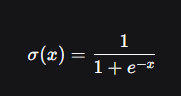

- Saida : entre 0 e 1
- uso : camada de saida para **classificação binaria ( é ou nao é)**
- Problema: saturação para valores extremos (gradiente proximo de zero), vanish gradient

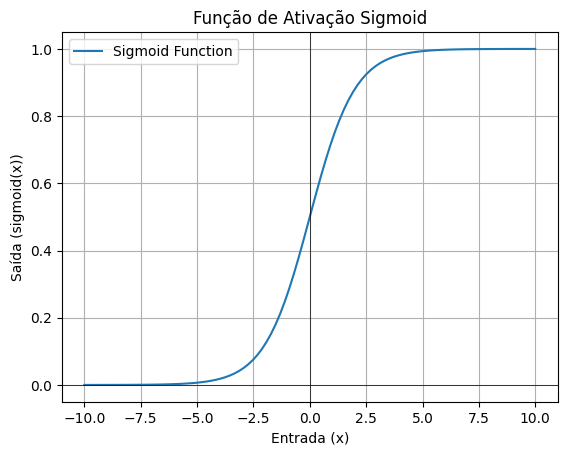

Entradas: [-10  -5   0   5  10]
Saídas após aplicar a Sigmoid: [4.53978687e-05 6.69285092e-03 5.00000000e-01 9.93307149e-01
 9.99954602e-01]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Função Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Gerar um intervalo de valores para entrada (x)
x_values = np.linspace(-10, 10, 100)

# Aplicar a função sigmoid para os valores de x
sigmoid_values = sigmoid(x_values)

# Plotando a função Sigmoid
plt.plot(x_values, sigmoid_values, label='Sigmoid Function')
plt.title('Função de Ativação Sigmoid')
plt.xlabel('Entrada (x)')
plt.ylabel('Saída (sigmoid(x))')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()

# Exemplo de uso da função Sigmoid
inputs = np.array([-10, -5, 0, 5, 10])
outputs = sigmoid(inputs)
print("Entradas:", inputs)
print("Saídas após aplicar a Sigmoid:", outputs)

Interpretando o gráfico acima: A função se comporta com entradas variando de -10 até 10. Ela tem uma forma de 's', sendo 0 se x <0 e 1 p/ x>0. Isso faz dela muito util para representar probabilidades

Importancia da sigmoid : 
- Limitação de valores : Comprime os valores no intervalo (0,1), tornando-a ideal p classificação binária.
- Outro fato: A simplicidade da derivada usada pela sigmoid.

### Função Tanh (Tangente hiperbólica)

Bastante similar com sigmoid, mas mapeia a entrada para o intervalo (-1 e 1), o que pode ser util em algumas redes, pois os dados sao centralizados em 0

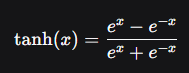

- Saida : entre -1 e 1
- Vantagem : Centrada em zero, melhor fluxo gradiente que sigmoid
- Problema : ainda satura


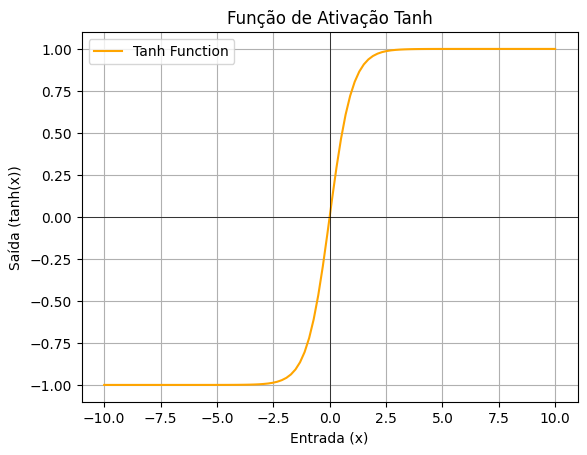

Entradas: [-10  -5   0   5  10]
Saídas após aplicar a Tanh: [-1.        -0.9999092  0.         0.9999092  1.       ]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Função Tanh
def tanh(x):
    return np.tanh(x)

# Gerar um intervalo de valores para entrada (x)
x_values = np.linspace(-10, 10, 100)

# Aplicar a função tanh para os valores de x
tanh_values = tanh(x_values)

# Plotando a função Tanh
plt.plot(x_values, tanh_values, label='Tanh Function', color='orange')
plt.title('Função de Ativação Tanh')
plt.xlabel('Entrada (x)')
plt.ylabel('Saída (tanh(x))')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()

# Exemplo de uso da função Tanh
inputs = np.array([-10, -5, 0, 5, 10])
outputs = tanh(inputs)
print("Entradas:", inputs)
print("Saídas após aplicar a Tanh:", outputs)

Analisando as informações:

- Gráfico : O grafico mostra que se aproxima de -1 para entradas negativas e de 1 para entradas positivas. Para valores proximos de zero, a função tanh retorna valores proximos de zero, tornando-a mais sensivel as pequenas variações perto da origem

- Derivada simples : tanh'(x) = 1 - tanh²(x)

### ReLU( Rectified Linear Unit)
É uma das funções mais utilizadas devido a sua simplicidade e eficiencia computacional.

    ReLU(x) = max(0,x)

- Vantagens : computacionalmente eficiente, nao satura para x>0, acelera convergência.
- Desvantagem : neuronios podem 'morrer'(saida sempre 0) se ficarem na região negativa

-> Variantes : LeakyRelu, ReLU, ELU...

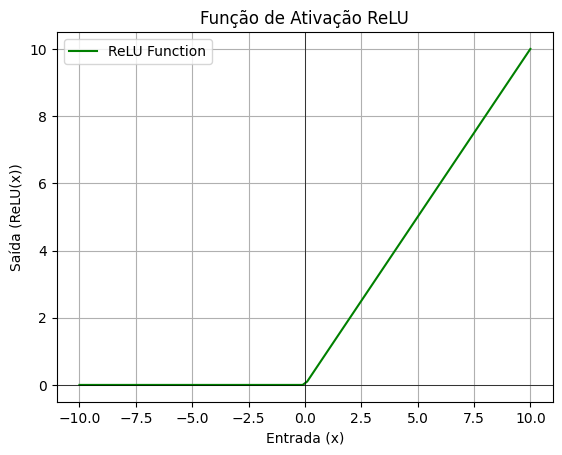

Entradas: [-10  -5   0   5  10]
Saídas após aplicar a ReLU: [ 0  0  0  5 10]


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Função ReLU
def relu(x):
    return np.maximum(0, x)

# Gerar um intervalo de valores para entrada (x)
x_values = np.linspace(-10, 10, 100)

# Aplicar a função ReLU para os valores de x
relu_values = relu(x_values)

# Plotando a função ReLU
plt.plot(x_values, relu_values, label='ReLU Function', color='green')
plt.title('Função de Ativação ReLU')
plt.xlabel('Entrada (x)')
plt.ylabel('Saída (ReLU(x))')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()

# Exemplo de uso da função ReLU
inputs = np.array([-10, -5, 0, 5, 10])
outputs = relu(inputs)
print("Entradas:", inputs)
print("Saídas após aplicar a ReLU:", outputs)

Interpretando as informações :

- Gráfico : Bastante simples. Para entradas negativas, sua saida é 0. Para entradas positivas, a saida é igual a entrada. Fazendo a relu ser bastante eficiente.

- Exemplo de aplicação : O comportamento da ReLU é claramente observado, onde qualquer valor negativo se torna zero e os valores positivos permanecem.

Importancia :
- Ao contrário da função sigmoid, que satura para valores muito positivos ou negativos, a ReLU resolve esse problema, permitindo que a rede aprenda de maneira mais eficiente.

- Simplicidade e eficiencia

- Ativações Sparsity : Relu cria ativação esparsa, ou seja, muitas unidades da rede neural terão saída zero, o que ajuda a rede a ser mais eficiente


### Softmax

A softmax é uma função muito utilizada na camada de saida da rede neural para problemas de classificação multi-classe. Ela converte um vetor de valores reais em uma distribuição de probabilidade, ou seja, trasnforma as saidas da rede para que eles representem a probabilidade de cada classe.

Sua função:

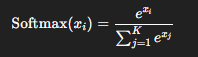



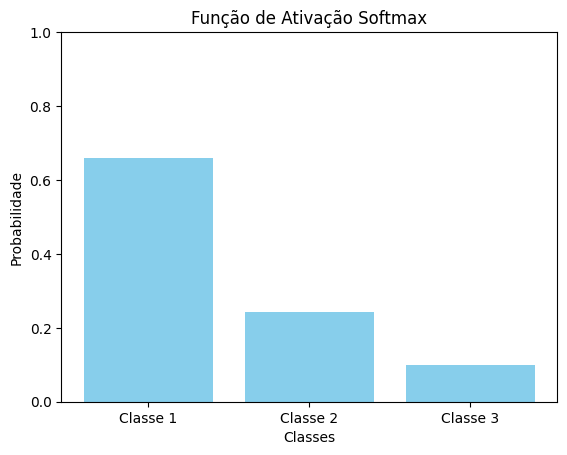

Valores de entrada: [2.  1.  0.1]
Saídas após aplicar a Softmax: [0.65900114 0.24243297 0.09856589]


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Função Softmax
def softmax(x):
    e_x = np.exp(x - np.max(x))  # Subtração de np.max(x) para estabilidade numérica
    return e_x / e_x.sum(axis=0, keepdims=True)

# Gerar um vetor de valores (simulando as saídas de uma rede neural)
x_values = np.array([2.0, 1.0, 0.1])

# Aplicar a função Softmax para os valores de x
softmax_values = softmax(x_values)

# Plotando a função Softmax
plt.bar(range(len(x_values)), softmax_values, tick_label=['Classe 1', 'Classe 2', 'Classe 3'], color='skyblue')
plt.title('Função de Ativação Softmax')
plt.xlabel('Classes')
plt.ylabel('Probabilidade')
plt.ylim(0, 1)
plt.show()

# Exemplo de uso da função Softmax
print("Valores de entrada:", x_values)
print("Saídas após aplicar a Softmax:", softmax_values)

Informações :

- Grafico : Moostra uma distribuição de probabilidades das classes após a aplicação do softmax. Gerando um grafico de barras com as probabilidades de cada classe, onde a soma =1.

- Exemplo de aplicação : O codigo aplica softmax a um vetor de valores simulando as saidas de uma rede e imporime as possibilidades dentro das classes

Importancia :
- Transformação para probablidade : Crucial em problemas de classificação multi-classe, pois converte a sadida em probabilidades.

- Distribuição normalizada : Sao normalizadas para que somem 1, o que é essencial para fazer uma boa previsão.

- Ajuste de peso: Durante o treinamento o erro é calculado comparando a classe real com a classe de maior probabilidade, permitindo ajustar os pesos com base no gradiente 


## Funções de perda

### O papel da função de perda

    Função de perda/custo quantifica o erro entre as predições do modelo e os valores reais.O objetivo do treinament o é minimizar essa perda


### Erro médio quadrático (MSE)

É muito utilizada em problemas de regressão, onde o objetivo é minimizar a diferença entre os valores reais e os valores preditos pela rede neural.

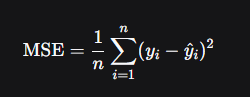

**-> Quanto menor o valor do MSE, melhor! <-**


- Uso : Usada em problemas de **regressão**

- Penaliza erros grandes devido ao quadrado na formula

- Tem uma derivada simples e é usada para ajustar os pesos da rede durante o treinamento


In [28]:
#Regressão linear + mse

import numpy as np
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


#Carregando dataset 
california = fetch_california_housing()
X = california.data
y = california.target

#Dividindo o dataset em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Criando o modelo de regressão linear
model = LinearRegression()
#Treinando o modelo
model.fit(X_train, y_train)
#Fazendo previsões
y_pred = model.predict(X_test)
#Calculando o erro quadrático médio
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.5558915986952425


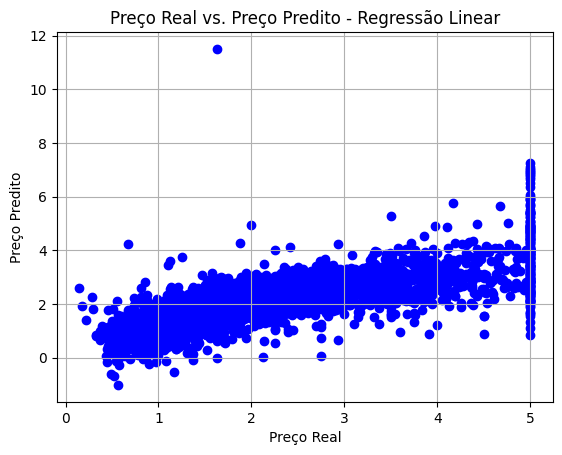

Erro Quadrático Médio (MSE): 0.5558915986952425
Coeficientes da regressão: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercepto: -37.02327770606397


In [29]:
# Visualizar a comparação entre o preço real e o preço predito
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel('Preço Real')
plt.ylabel('Preço Predito')
plt.title('Preço Real vs. Preço Predito - Regressão Linear')
plt.grid(True)
plt.show()

# Exibir o MSE e os coeficientes
print(f'Erro Quadrático Médio (MSE): {mse}')
print(f'Coeficientes da regressão: {model.coef_}')
print(f'Intercepto: {model.intercept_}')

Resultados que devemos esperar:

    - Grafico : MOstra uma comparação dos 2, permitindo ver o quao bom o modelo se ajustou nos dados.
    
    - MSE : Quanto menor o valor do MSE,melhor o modelo.

### Entropria cruzada 

Função de perda muito utilizada em problemas de **classificação**, pois mede a dissimilaridade entre a distribuição de probablidade real (as saidas desejadas) e a distribuição de probabilidade prevista(as saídas do modelo)

A entropia cruzada tem duas formulas que podem ser utilizadas, classificação binária e classificação multiclasse(com softmax)


**Classificação binária:**
    Para classificação binária, onde as saidas sao 0e 1, a fomula é :
    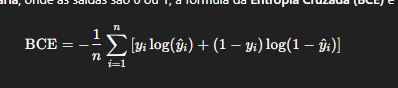

**Multiclasse:**
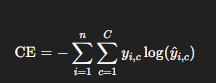


- Uso : Entropia cruzada para classifcação 


**Como interpretar o valor ?**
    Valor baixo : Modelo esta fazendo as predições com alta confiança e precisão, ou seja, suas probabilidades estao proximas dos valores reais.

    Valor alto : Baixa confiança e precisão, logo estamos com as precisões erradas.

In [30]:
#Exemplo de classificação binária
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.datasets import make_classification

# Gerar dados binários de exemplo
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=42)

# Criar e treinar o modelo de Regressão Logística
model = LogisticRegression()
model.fit(X, y)

# Fazer previsões (probabilidades)
y_pred_prob = model.predict_proba(X)[:, 1]  # Probabilidade da classe 1

# Calcular a Entropia Cruzada (Log Loss)
bce = log_loss(y, y_pred_prob)
print(f"Erro de Entropia Cruzada (BCE): {bce}")

Erro de Entropia Cruzada (BCE): 0.09052225748540221


In [31]:
#Classificação multiclasse 
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

# Carregar o dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividir o dataset em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo de Regressão Logística (multiclasse)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Fazer previsões (probabilidades)
y_pred_prob = model.predict_proba(X_test)

# Calcular a Entropia Cruzada (Log Loss) para classificação multiclasse
ce = log_loss(y_test, y_pred_prob)
print(f"Erro de Entropia Cruzada (CE) para Classificação Multiclasse: {ce}")

Erro de Entropia Cruzada (CE) para Classificação Multiclasse: 0.11114980830165229


### Escolha da função de perda

Aqui está a tabela em formato Markdown:

| **Tipo de problema**                               | **Função de perda**                    | **Ativação de saída** |
|----------------------------------------------------|----------------------------------------|-----------------------|
| **Regressão**                                      | MSE / MAE                              | Linear               |
| **Classificação binária**                          | Binary Cross-Entropy                   | Sigmoid              |
| **Classificação multiclasse**                      | Categorical Cross-Entropy              | Softmax              |
| **Classificação multiclasse com rótulos esparsos** | Sparse Categorical Cross-Entropy       | Softmax              |

Essa tabela organiza de forma clara os tipos de problemas de aprendizado de máquina, suas funções de perda associadas e as funções de ativação de saída recomendadas.

## Otimizadores

### 6.1 Gradiente Descendente

O gradiente descendente é um algoritmo de otimização usado para ajustar os pesos do modelo, minimizando a função de perda. Ele atualiza os pesos na direção oposta ao gradiente da função de perda, com o objetivo de reduzir o erro.

A fórmula de atualização dos pesos é:

$$w \leftarrow w - \eta \nabla_w L$$

Onde:

- $w$ são os pesos do modelo
- $\eta$ é a taxa de aprendizado (learning rate), que controla o tamanho dos passos dados na direção do gradiente
- $\nabla_w L$ é o gradiente da função de perda $L$ em relação aos pesos $w$

#### Por que na direção oposta?

A razão pela qual os pesos são atualizados na direção oposta ao gradiente no gradiente descendente é para **minimizar a função de perda**.

**Intuição por trás da direção oposta ao gradiente:**

- **Gradiente**: O gradiente de uma função em relação a uma variável (neste caso, os pesos $w$) é um vetor que aponta para a direção da taxa de variação máxima da função. Em outras palavras, o gradiente nos diz para qual direção a função de perda **aumenta** mais rapidamente.

- **Objetivo**: O objetivo do treinamento é **minimizar** a função de perda (erro). Ou seja, queremos mover os pesos de forma a reduzir o erro do modelo.

- **Direção oposta**: Se o gradiente aponta na direção onde a função de perda aumenta, a direção oposta ao gradiente será a direção onde a função de perda **diminui**. Então, para minimizar o erro, devemos ajustar os pesos na direção oposta ao gradiente.

**Visualização:**

Imagine um gráfico de uma função de perda simples, onde o eixo $x$ representa os pesos $w$ e o eixo $y$ representa o valor da função de perda $L(w)$.

- O gradiente é a inclinação da função de perda em relação aos pesos.
- Se o gradiente for positivo, significa que a função de perda está aumentando à medida que $w$ aumenta, e devemos ajustar $w$ para diminuir a função de perda (o que equivale a mover-se na direção oposta ao gradiente).
- Se o gradiente for negativo, a função de perda está diminuindo à medida que $w$ aumenta, então ainda precisamos mover os pesos na direção oposta ao gradiente para chegar ao ponto mínimo.

**Conclusão:**

Portanto, a razão de atualizar os pesos na direção oposta ao gradiente é porque queremos mover os pesos para uma região onde a função de perda seja menor. Isso é fundamental para que o modelo aprenda a partir dos dados, ajustando os pesos de maneira a minimizar o erro ao longo do treinamento.

### 6.2 Stochastic Gradient Descent (SGD)

O **Stochastic Gradient Descent (SGD)** é uma variação do gradiente descendente que, em vez de calcular o gradiente com base em todo o conjunto de dados, utiliza um **minibatch aleatório** a cada iteração.

**Vantagens do SGD:**

- **Mais rápido**: Como o SGD utiliza um minibatch em vez do conjunto completo de dados, ele é mais rápido para calcular o gradiente e realizar a atualização dos pesos.

- **Escapa de Mínimos Locais**: O SGD tem uma tendência a oscilar e, portanto, pode escapar de mínimos locais, chegando a uma solução melhor do que o gradiente descendente tradicional.

**Desvantagens do SGD:**

- **Oscilações na trajetória**: Como o modelo é atualizado com base em um minibatch aleatório a cada iteração, ele pode apresentar oscilações na trajetória de convergência. Isso significa que, embora o modelo avance em direção ao mínimo, ele pode dar "passos errados" temporários, o que pode retardar a convergência.

**Pseudocódigo do SGD:**

```python
# Pseudocódigo do Stochastic Gradient Descent (SGD)
for epoch in range(epochs):
    for batch in dataloader:
        loss = compute_loss(batch)          # Calcular a perda do minibatch
        loss.backward()                     # Calcular o gradiente
        optimizer.step()                    # Atualizar os pesos (w -= lr * grad)
        optimizer.zero_grad()               # Zerando os gradientes para a próxima iteração
```

**Explicação do Pseudocódigo:**

- **Loop pelas épocas (epochs)**: O SGD é executado por várias épocas. Cada época corresponde a uma passagem completa pelo dataset (ou por seus minibatches).

- **Loop pelo minibatch (batch)**: O dataset é dividido em minibatches (subconjuntos aleatórios dos dados). Em cada iteração, o modelo é atualizado com base em um minibatch.

- **Cálculo da perda (loss)**: A função de perda é calculada para o minibatch atual. A função `compute_loss(batch)` retorna a perda para esse conjunto de dados.

- **Cálculo do gradiente**: Usando `loss.backward()`, o gradiente da função de perda é calculado em relação aos pesos da rede.

- **Atualização dos pesos**: A função `optimizer.step()` é responsável por atualizar os pesos, aplicando o gradiente descendente com o learning rate (taxa de aprendizado).

- **Zerando os gradientes**: `optimizer.zero_grad()` é usado para limpar os gradientes acumulados da iteração anterior, preparando o modelo para a próxima iteração.

### 6.3 Momentum

O **Momentum** é uma técnica de otimização que acumula os gradientes das iterações anteriores para suavizar e acelerar a atualização dos pesos. Ele é inspirado pela física, onde o momento de um objeto é acumulado ao longo do tempo.

**Fórmula do Momentum:**

**Cálculo do Momentum:**

$$v_t = \beta v_{t-1} + (1 - \beta) \nabla_w L$$

Onde:

- $v_t$ é o momento acumulado na iteração $t$
- $\beta$ é o fator de momentum (geralmente próximo de 1, como 0.9)
- $v_{t-1}$ é o momento acumulado da iteração anterior
- $\nabla_w L$ é o gradiente da função de perda em relação aos pesos $w$

**Atualização dos Pesos:**

$$w \leftarrow w - \eta v_t$$

Onde:

- $w$ são os pesos do modelo
- $\eta$ é a taxa de aprendizado (learning rate)
- $v_t$ é o momento calculado

**Vantagens do Momentum:**

- **Acelera a convergência**: Ao acumular gradientes de iterações anteriores, o Momentum ajuda a acelerar a convergência, permitindo que o modelo faça atualizações mais rápidas e diretas.

- **Reduz as oscilações**: O uso do Momentum ajuda a suavizar as oscilações nas atualizações dos pesos, o que é útil em regiões do espaço de parâmetros com grandes flutuações.

**Explicação:**

O Momentum acumula o gradiente das iterações anteriores, de forma que a atualização dos pesos é influenciada não só pelo gradiente da iteração atual, mas também pelo gradiente das iterações passadas.

Esse "acúmulo" faz com que o modelo tenha mais "inércia" em sua direção de atualização, permitindo que ele "escape" de mínimos locais mais rapidamente e se mova com mais velocidade em direções promissoras.

### 6.4 Adam (Adaptive Moment Estimation)

O **Adam** é um algoritmo de otimização amplamente utilizado, que combina as vantagens do Momentum e da adaptação da taxa de aprendizado. Ele calcula momentos de gradiente de primeiro e segundo ordem para adaptar a taxa de aprendizado de cada parâmetro de forma eficiente.

**Como o Adam Funciona:**

**Momentos de Primeiro e Segundo Ordem:**

- **Primeiro momento (m)**: Média exponencial do gradiente ($\nabla_w L$), similar ao Momentum.
- **Segundo momento (v)**: Média exponencial do quadrado do gradiente ($\nabla_w L^2$).

**Cálculo dos Momentos:**

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla_w L$$

$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) (\nabla_w L)^2$$

Onde:

- $m_t$ é o primeiro momento (gradiente)
- $v_t$ é o segundo momento (quadrado do gradiente)
- $\beta_1$ e $\beta_2$ são os coeficientes de momento (geralmente, $\beta_1 = 0.9$ e $\beta_2 = 0.999$)

**Correção de Bias:**

Como os momentos $m_t$ e $v_t$ inicializam com zero, é necessário corrigir o viés de inicialização:

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$$

$$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Atualização dos Pesos:**

$$w \leftarrow w - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

Onde:

- $\eta$ é a taxa de aprendizado global
- $\epsilon$ é um pequeno valor para evitar divisão por zero (geralmente $\epsilon = 1e-7$)

**Vantagens do Adam:**

- **Adaptação da Taxa de Aprendizado**: A principal vantagem do Adam é que ele adapta automaticamente a taxa de aprendizado para cada parâmetro, o que ajuda em diferentes tipos de problemas, especialmente quando o espaço de parâmetros é grande.

- **Eficiência Computacional**: Combina a eficiência do Momentum com a adaptação do gradiente, sendo especialmente eficaz em problemas de grande escala.

In [ ]:
import tensorflow as tf

# Criar um modelo simples (exemplo de rede neural)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compilar o modelo usando o otimizador Adam
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Resumo do modelo
model.summary()

**Explicação do Código:**

- **Modelo Simples**: Este código cria um modelo simples de rede neural com uma camada densa de 64 neurônios e uma camada de saída de 10 neurônios (para uma classificação multiclasse).

- **Adam como Otimizador**: O otimizador Adam é usado no modelo com uma taxa de aprendizado de 0.001. O Adam combina as vantagens do Momentum e da adaptação da taxa de aprendizado para cada parâmetro.

**Conclusão:**

Adam é um dos otimizadores mais populares por sua robustez e eficiência em muitos tipos de problemas de aprendizado de máquina, especialmente em redes neurais profundas.

Ele adapta a taxa de aprendizado para cada parâmetro com base nos gradientes de primeiro e segundo momentos, acelerando a convergência e melhorando a performance do modelo.

Com o Adam, o treinamento pode ser mais rápido e eficiente, reduzindo a necessidade de ajuste manual da taxa de aprendizado, o que o torna a escolha preferida para muitos problemas de aprendizado profundo.

### 6.5 Comparação de otimizadores

| **Otimizador**        | **Vantagens**                                | **Desvantagens**                              |
|-----------------------|----------------------------------------------|-----------------------------------------------|
| **SGD**               | Simples, bem compreendido                   | Lento, sensível à taxa de aprendizado        |
| **SGD + Momentum**    | Mais rápido que o SGD                       | Parâmetro extra (momento)                    |
| **Adam**              | Robusto, adaptativo, rápido                 | Pode não generalizar tão bem em alguns casos |

**Explicação:**

**SGD (Stochastic Gradient Descent):**
- **Vantagens**: Simples e fácil de entender, muito utilizado.
- **Desvantagens**: Lento para convergir em datasets grandes, e muito sensível à escolha da taxa de aprendizado.

**SGD + Momentum:**
- **Vantagens**: Acelera o processo de convergência em comparação ao SGD, ajudando a escapar de mínimos locais.
- **Desvantagens**: Introduz um parâmetro extra ($\beta$) que precisa ser ajustado.

**Adam:**
- **Vantagens**: Adaptativo, ajusta a taxa de aprendizado de cada parâmetro e é rápido e robusto.
- **Desvantagens**: Pode não generalizar tão bem em alguns casos, especialmente quando há pouco dado ou em problemas específicos, onde outros otimizadores podem ter um desempenho melhor.

### MAE no teste: 1.58, é bom?

O valor de **MAE (Mean Absolute Error)**, que no seu caso é **1.58**, é uma medida de erro absoluto médio entre os valores reais e as previsões do modelo. A interpretação do valor de MAE depende do contexto do seu problema específico.

**O que é o MAE?**

O MAE é calculado como a média das diferenças absolutas entre os valores reais e as previsões feitas pelo modelo. A fórmula é a seguinte:

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Onde:

- $y_i$ são os valores reais
- $\hat{y}_i$ são os valores preditos pelo modelo
- $n$ é o número total de amostras

O MAE representa o erro médio absoluto entre as previsões e os valores reais, ou seja, ele nos dá uma ideia de quão "fora de controle" estão as previsões do modelo em termos de magnitude.

**Como Avaliar um MAE de 1.58?**

**Considerações para Avaliar o MAE:**

1. **Escala dos Dados**: O que realmente importa é a escala dos dados com os quais você está trabalhando. Por exemplo:
   - Se os valores reais de $y$ variam entre 0 e 10, um MAE de 1.58 pode ser considerado razoável, significando que, em média, as previsões estão erradas em torno de 1.58 unidades.
   - Se os valores reais de $y$ variam de 0 a 1000, um MAE de 1.58 seria muito baixo e indicaria um bom desempenho do modelo.

2. **Comparação com outras Métricas ou Modelos**: Você pode comparar o MAE com o desempenho de outros modelos ou outras métricas de erro, como o MSE ou RMSE. Um MAE de 1.58 pode ser bom se não houver grandes variações no problema, mas, se o modelo for muito simples, pode ser necessário um MAE menor para indicar um bom desempenho.

3. **Tolerância ao Erro**: Dependendo do domínio do problema, um erro de 1.58 pode ser aceitável ou não. Por exemplo:
   - Na previsão do tempo, um erro de 1.58 graus pode ser aceitável dependendo da precisão exigida.
   - Em finanças, um erro de 1.58 pode ser inaceitável se estiver lidando com valores muito pequenos ou grandes transações financeiras.

**Dicas para Avaliar:**

- Compare o MAE com o alcance dos valores reais.
- Compare com a distribuição dos erros (veja se as previsões estão consistentemente erradas por um valor muito alto ou baixo).
- Compare com o desempenho de modelos anteriores ou benchmarking para entender se o seu modelo está gerando bons resultados.

**Conclusão:**

Se um MAE de 1.58 é "bom" depende do seu caso específico e da escala dos dados. Se os dados variam amplamente e esse erro está dentro de uma margem aceitável, então sim, o resultado pode ser considerado bom. Caso contrário, talvez seja necessário ajustar o modelo para melhorar a precisão das previsões.

## 7.4 Compilação e treinamento

No Keras, o processo de compilação e treinamento de um modelo envolve dois métodos principais: o método `compile()` para configurar o modelo e o método `fit()` para treinar o modelo.

### Método compile()

O método `compile()` é usado para configurar o modelo antes do treinamento. Ele define:

- **Otimizador**: Determina o algoritmo usado para atualizar os pesos do modelo, como `'sgd'` (Stochastic Gradient Descent), `'adam'`, entre outros.

- **Função de perda**: Define a função de perda que será usada para medir o erro do modelo durante o treinamento, como `'mse'` (Mean Squared Error), `'categorical_crossentropy'`, etc.

- **Métricas**: Define as métricas que serão monitoradas durante o treinamento, como `'accuracy'`, `'mae'` (Mean Absolute Error), entre outras.

**Exemplo de uso do compile():**

```python
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])
```

### Método fit()

O método `fit()` é utilizado para treinar o modelo. Ele aceita vários parâmetros importantes:

- **epochs**: Número de passagens completas pelo dataset. Cada época é uma iteração onde o modelo passa por todos os dados de treinamento.

- **batch_size**: Número de amostras por atualização de gradiente. Se você usar um minibatch (ao invés de toda a base de dados), o modelo é treinado em "lotes" de dados. O ajuste do batch_size pode influenciar o desempenho e a convergência.

- **validation_split**: Fração dos dados de treino que será usada para validação. Geralmente, um valor entre 0 e 1, representando a porcentagem dos dados de treino reservados para validação.

- **callbacks**: Permite a execução de funções adicionais durante o treinamento, como o early stopping, que interrompe o treinamento se a validação não melhorar após um número específico de épocas.

**Exemplo de uso do fit():**

```python
model.fit(X_train, y_train, 
          epochs=10, 
          batch_size=32, 
          validation_split=0.2, 
          callbacks=[early_stopping])
```

Onde `early_stopping` pode ser um callback que interrompe o treinamento se a perda de validação não melhorar por um número determinado de épocas.

### Resumo dos Parâmetros:

| **Parâmetro**       | **Descrição**                                                                 |
|---------------------|-------------------------------------------------------------------------------|
| `optimizer`         | Algoritmo usado para otimizar os pesos (ex: `'sgd'`, `'adam'`)              |
| `loss`              | Função de perda usada para medir o erro (ex: `'mse'`, `'categorical_crossentropy'`) |
| `metrics`           | Métricas para monitoramento do modelo (ex: `'accuracy'`, `'mae'`)           |
| `epochs`            | Número de passagens completas pelo dataset                                   |
| `batch_size`        | Número de amostras por atualização de gradiente                             |
| `validation_split`  | Fração dos dados de treino usada para validação                             |
| `callbacks`         | Ações adicionais durante o treinamento, como early stopping                  |

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# Criando um modelo simples
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compilando o modelo
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Configurando o early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

# Nota: Para treinar, você precisaria de dados X_train e y_train
# Exemplo de como treinar (descomente quando tiver os dados):
# model.fit(X_train, y_train, 
#           epochs=10, 
#           batch_size=32, 
#           validation_split=0.2, 
#           callbacks=[early_stopping])

**Conclusão:**

- O método `compile()` configura o modelo para treinamento, escolhendo o otimizador, a função de perda e as métricas.

- O método `fit()` realiza o treinamento do modelo, com a possibilidade de ajustar o número de épocas, o tamanho do minibatch, usar validação e callbacks como o early stopping.

Esse processo de compilação e treinamento é a base para o treinamento de modelos no Keras/TensorFlow e é fundamental para otimizar e validar redes neurais.

## Classificação de Imagens com MNIST

### 9.1 O dataset MNIST

O **MNIST (Modified National Institute of Standards and Technology)** é um dos datasets mais famosos em Machine Learning e Deep Learning. Ele contém:

- **60.000 imagens de treino**
- **10.000 imagens de teste**
- **Dimensão**: 28x28 pixels (escala de cinza)
- **Classes**: 10 dígitos (0-9)

Cada pixel tem um valor entre 0 (preto) e 255 (branco), representando a intensidade do tom de cinza.

**Por que o MNIST é importante?**

- É um benchmark clássico para algoritmos de classificação
- Simples o suficiente para treinar rapidamente
- Complexo o suficiente para demonstrar conceitos fundamentais
- Amplamente utilizado em tutoriais e pesquisas

O MNIST é considerado o "Hello World" do Deep Learning!

### 9.2 Preparação dos dados

Antes de treinar um modelo, precisamos preparar os dados:

**Etapas de preparação:**

1. **Carregar o dataset**: Importar os dados de treino e teste
2. **Normalização**: Transformar os valores dos pixels de [0, 255] para [0, 1]
3. **Reshape**: Ajustar as dimensões conforme necessário (para MLP: achatar 28x28 → 784)
4. **One-hot encoding** (opcional): Converter labels para formato categórico

**Por que normalizar?**

A normalização ajuda o modelo a convergir mais rapidamente durante o treinamento, pois mantém os valores em uma escala consistente.

Forma dos dados de treino: (60000, 28, 28)
Forma dos dados de teste: (10000, 28, 28)
Forma dos labels de treino: (60000,)
Forma dos labels de teste: (10000,)


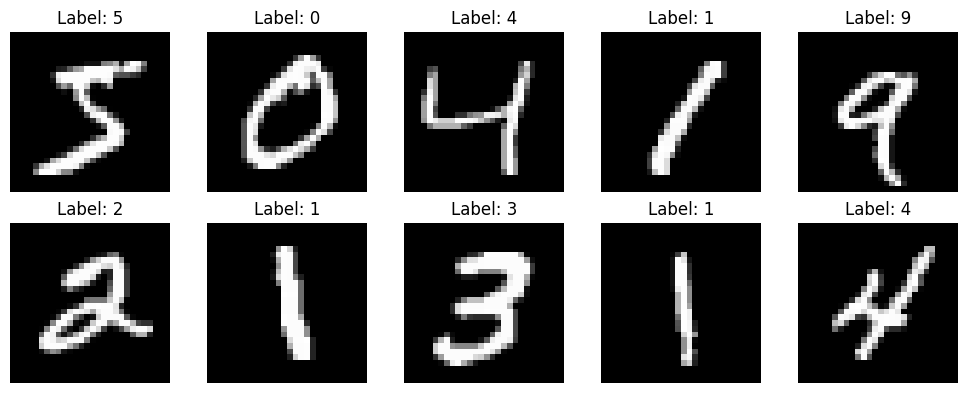


Valor mínimo dos pixels: 0
Valor máximo dos pixels: 255


In [1]:
# Importar bibliotecas necessárias
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Carregar o dataset MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Verificar as dimensões
print(f"Forma dos dados de treino: {X_train.shape}")
print(f"Forma dos dados de teste: {X_test.shape}")
print(f"Forma dos labels de treino: {y_train.shape}")
print(f"Forma dos labels de teste: {y_test.shape}")

# Visualizar algumas imagens
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Verificar os valores dos pixels
print(f"\nValor mínimo dos pixels: {X_train.min()}")
print(f"Valor máximo dos pixels: {X_train.max()}")

In [ ]:
# Pré-processamento dos dados

# 1. Normalização: Converter valores de [0, 255] para [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. Reshape: Achatar as imagens de 28x28 para vetor de 784
X_train_flatten = X_train.reshape(-1, 28 * 28)  # (60000, 784)
X_test_flatten = X_test.reshape(-1, 28 * 28)    # (10000, 784)

print(f"Forma após flatten (treino): {X_train_flatten.shape}")
print(f"Forma após flatten (teste): {X_test_flatten.shape}")

# 3. Verificar normalização
print(f"\nApós normalização:")
print(f"Valor mínimo: {X_train_flatten.min()}")
print(f"Valor máximo: {X_train_flatten.max()}")

# Os labels já estão no formato correto (0-9)
# Para usar com categorical_crossentropy, podemos converter para one-hot:
# y_train_onehot = keras.utils.to_categorical(y_train, 10)
# y_test_onehot = keras.utils.to_categorical(y_test, 10)

# Mas vamos usar sparse_categorical_crossentropy, que aceita labels inteiros
print(f"\nExemplo de labels: {y_train[:10]}")

### 9.3 Construindo uma MLP para MNIST

Agora vamos construir uma **Multilayer Perceptron (MLP)** para classificar os dígitos do MNIST.

**Arquitetura da nossa rede:**

1. **Camada de entrada**: 784 neurônios (28×28 pixels achatados)
2. **Camada oculta 1**: 128 neurônios com ativação ReLU
3. **Camada oculta 2**: 64 neurônios com ativação ReLU
4. **Camada de saída**: 10 neurônios com ativação Softmax (uma para cada dígito)

**Escolhas de design:**

- **ReLU nas camadas ocultas**: Introduz não-linearidade e evita vanishing gradient
- **Softmax na saída**: Converte as saídas em probabilidades que somam 1
- **Sparse Categorical Crossentropy**: Função de perda para classificação multiclasse com labels inteiros
- **Adam**: Otimizador adaptativo que ajusta a taxa de aprendizado automaticamente

In [ ]:
# Construir o modelo MLP
model = keras.Sequential([
    # Camada de entrada (implícita) + primeira camada oculta
    keras.layers.Dense(128, activation='relu', input_shape=(784,), name='hidden_layer_1'),
    
    # Segunda camada oculta
    keras.layers.Dense(64, activation='relu', name='hidden_layer_2'),
    
    # Camada de saída
    keras.layers.Dense(10, activation='softmax', name='output_layer')
])

# Visualizar a arquitetura do modelo
model.summary()

# Compilar o modelo
model.compile(
    optimizer='adam',                           # Otimizador Adam
    loss='sparse_categorical_crossentropy',     # Função de perda para classificação multiclasse
    metrics=['accuracy']                        # Métrica de avaliação
)

print("\n✓ Modelo construído e compilado com sucesso!")

### 9.4 Treinamento e avaliação

Agora vamos treinar o modelo e avaliar seu desempenho!

**Hiperparâmetros de treinamento:**

- **Epochs**: 10 (número de passagens completas pelo dataset)
- **Batch size**: 32 (número de amostras processadas antes de atualizar os pesos)
- **Validation split**: 20% dos dados de treino serão usados para validação

Durante o treinamento, vamos monitorar:
- **Loss (perda)**: Quanto menor, melhor
- **Accuracy (acurácia)**: Quanto maior, melhor

In [ ]:
# Treinar o modelo
print("Iniciando o treinamento...\n")

history = model.fit(
    X_train_flatten,           # Dados de treino
    y_train,                   # Labels de treino
    epochs=10,                 # Número de épocas
    batch_size=32,             # Tamanho do batch
    validation_split=0.2,      # 20% dos dados para validação
    verbose=1                  # Mostrar progresso
)

print("\n✓ Treinamento concluído!")

In [ ]:
# Avaliar o modelo no conjunto de teste
print("Avaliando o modelo no conjunto de teste...\n")

test_loss, test_accuracy = model.evaluate(X_test_flatten, y_test, verbose=0)

print(f"\n{'='*50}")
print(f"Resultados no Conjunto de Teste:")
print(f"{'='*50}")
print(f"Loss (Perda): {test_loss:.4f}")
print(f"Accuracy (Acurácia): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'='*50}")

# Fazer predições em algumas amostras
predictions = model.predict(X_test_flatten[:5], verbose=0)

print("\nExemplo de predições (primeiras 5 amostras):")
for i in range(5):
    predicted_class = np.argmax(predictions[i])
    true_class = y_test[i]
    confidence = predictions[i][predicted_class] * 100
    
    status = "✓" if predicted_class == true_class else "✗"
    print(f"{status} Amostra {i+1}: Predito={predicted_class}, Real={true_class}, Confiança={confidence:.2f}%")